# 07 — Extension synthesis (Part C)

## Purpose

Tie **Part A** (Notebook 05, virtual lesioning) and **Part B** (Notebook 06,
structural connectivity perturbation) into a single per-region picture and
quantify exactly *how* the two analyses agree or disagree.

Part C is a **synthesis layer**: no new heavy simulations. It loads
`data/vla_results.npz` and `data/sc_perturbation_results.npz`, computes
structural hubness on the spectral-normalised SC, joins everything into one
master table, and produces the figures + statistics that the report needs.

## What we already know going in

* **H1 — supported.** Eigenvector centrality predicts Part A driver strength
  (Spearman ρ ≈ +0.32 control, +0.41 glioma). Naive degree / strength do not.
* **H3 (tumour overlap) — partially supported** at top-5 of the *differential*
  ranking (p ≈ 0.01); dilutes by top-10.
* **H2 / H2b — rejected.** Damaging Part A drivers does *not* produce steeper
  K\* responses than damaging matched non-drivers, and does not push K\*_ctrl
  toward K\*_glio in the meaningful mild damage range.
* **Part A |ΔK| vs Part B mild slope — uncorrelated** (Spearman ρ = +0.15,
  p = 0.59).

The headline scientific question Part C must answer is therefore
**why functional leverage (Part A) and anatomical fragility (Part B) appear
to be dissociable network properties** in this Hopf + PLI + single-K
framework, and what (if anything) ties them together.

## Outputs

* `figures/hopf model/synthesis/fig1_hubness_vs_partA.png`
* `figures/hopf model/synthesis/fig2_partA_vs_partB.png`
* `figures/hopf model/synthesis/fig3_rank_heatmap.png`
* `figures/hopf model/synthesis/fig4_tumour_overlap_metrics.png`
* `data/part_c_master_table.csv` — per-region join of all metrics.
* `data/part_c_summary.npz` — saved correlations / overlap counts.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, spearmanr

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "project_paths.py").exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from project_paths import data_dir, figures_dir, find_project_root
from results_io import load_validated_npz
from network_analysis import (
    AAL78_LABELS,
    NETWORK_NAMES,
    NETWORK_COLORS,
    driver_strength,
    hypergeom_pvalue,
    normalize_weights,
    rank_high_first,
    structural_hubness,
    topn_indices,
)

ROOT = find_project_root(ROOT)
FIG_DIR = figures_dir("synthesis", root=ROOT)
DATA_DIR = data_dir(ROOT)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 300, "font.size": 11})

print(f"ROOT     : {ROOT}")
print(f"FIG_DIR  : {FIG_DIR}")
print(f"DATA_DIR : {DATA_DIR}")


ROOT     : c:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practical Biomedical Modelling\Functional-connectotomy
FIG_DIR  : c:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practical Biomedical Modelling\Functional-connectotomy\figures\hopf model\synthesis
DATA_DIR : c:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practical Biomedical Modelling\Functional-connectotomy\data


## 1. Load Part A and Part B results, plus structural connectivity

Sanity-check shapes and parameter universes — Part A and Part B must share
`VLA_K` and `VLA_LAM`, otherwise their K\* scales are not directly
comparable.


In [2]:
vla = load_validated_npz(DATA_DIR / "vla_results.npz")
scp = load_validated_npz(DATA_DIR / "sc_perturbation_results.npz")

assert np.array_equal(vla["VLA_K"], scp["VLA_K"]), (
    "Part A and Part B used different K grids - synthesis would be invalid"
)
assert float(np.atleast_1d(vla["VLA_LAM"])[0]) == float(np.atleast_1d(scp["VLA_LAM"])[0]), (
    "Part A and Part B used different lambda - synthesis would be invalid"
)

print("Part A keys:", list(vla.files))
print("Part B keys:", list(scp.files))
print()
print(f"K grid     : {vla['VLA_K'].size} values, range "
      f"[{vla['VLA_K'].min():.2f}, {vla['VLA_K'].max():.2f}]")
print(f"lambda     : {float(np.atleast_1d(vla['VLA_LAM'])[0])}")
print(f"Part B set : {len(scp['regions'])} regions "
      f"({int(scp['N_TOP'][0])} drivers + {int(scp['N_NULL'][0])} non-drivers)")
print(f"Part B ICs : {int(scp['SC_N_IC'][0])} per condition")

SC_EMP = normalize_weights(
    np.loadtxt(DATA_DIR / "structural_connectivity_matrix.csv", delimiter=","),
    method="spectral",
)
N_REGIONS = SC_EMP.shape[0]
print()
print(f"SC: {SC_EMP.shape}, spectral radius = "
      f"{np.max(np.abs(np.linalg.eigvalsh(SC_EMP))):.3f}")


Part A keys: ['dK_ctrl', 'dK_glio', 'dK_diff', 'mean_ctrl', 'mean_glio', 'mean_diff', 'Kfull_ctrl', 'Kfull_glio', 'VLA_K', 'VLA_LAM']
Part B keys: ['regions', 'region_kind', 'damage_levels', 'damage_mild', 'Kstar_ctrl', 'Kstar_glio', 'mean_Kc', 'mean_Kg', 'std_Kc', 'std_Kg', 'slopes_ctrl_mild', 'slopes_ctrl_full', 'slopes_glio_mild', 'slopes_glio_full', 'N_TOP', 'N_NULL', 'SC_N_IC', 'VLA_K', 'VLA_LAM', 'mean_ctrl_A', 'mean_glio_A']

K grid     : 60 values, range [0.50, 50.00]
λ          : 40.0
Part B set : 15 regions (10 drivers + 5 non-drivers)
Part B ICs : 50 per condition

SC: (78, 78), spectral radius = 1.000


## 2. Compute structural hubness for every region

For each of the 78 AAL regions on the spectral-normalised SC:

* **Degree** — number of incident edges (binarised at machine epsilon).
* **Strength** — sum of absolute edge weights (`Σ |w_ij|`).
* **Eigenvector centrality** — leading-eigenvector entry of `|W|`. This is
  the metric that predicted Part A ΔK in Notebook 05.

These are computed once and reused throughout Part C.


In [3]:
HUBNESS = structural_hubness(SC_EMP)
degree = HUBNESS["degree"]
strength = HUBNESS["strength"]
eigcent = HUBNESS["eigcent"]
print(f"Degree   : range [{degree.min()}, {degree.max()}], median {np.median(degree):.1f}")
print(f"Strength : range [{strength.min():.3f}, {strength.max():.3f}], median {np.median(strength):.3f}")
print(f"Eigcent  : range [{eigcent.min():.3f}, {eigcent.max():.3f}], median {np.median(eigcent):.3f}")


Degree   : range [3, 32], median 11.5
Strength : range [0.012, 1.775], median 0.525
Eigcent  : range [0.000, 0.381], median 0.018


## 3. Build the per-region master table

One row per AAL region (n = 78) with every metric available. The Part B
columns are NaN for regions that were not in the 15-region perturbation
sweep. Saved to `data/part_c_master_table.csv` for any later downstream use
(supplementary tables, plotting outside the notebook, etc.).


In [4]:
mean_ctrl_A = vla["mean_ctrl"]
mean_glio_A = vla["mean_glio"]
mean_diff_A = vla["mean_diff"]

# Part B per-region columns; NaN for non-tested regions.
slopes_ctrl_mild = np.full(N_REGIONS, np.nan)
slopes_ctrl_full = np.full(N_REGIONS, np.nan)
slopes_glio_mild = np.full(N_REGIONS, np.nan)
slopes_glio_full = np.full(N_REGIONS, np.nan)
gap_d0           = np.full(N_REGIONS, np.nan)
gap_d05          = np.full(N_REGIONS, np.nan)
gap_d1           = np.full(N_REGIONS, np.nan)
role             = np.array(["not tested"] * N_REGIONS, dtype="<U12")

for i, r in enumerate(scp["regions"]):
    slopes_ctrl_mild[r] = scp["slopes_ctrl_mild"][i]
    slopes_ctrl_full[r] = scp["slopes_ctrl_full"][i]
    slopes_glio_mild[r] = scp["slopes_glio_mild"][i]
    slopes_glio_full[r] = scp["slopes_glio_full"][i]
    gap_d0[r]           = scp["mean_Kc"][i, 0]  - scp["mean_Kg"][i, 0]
    gap_d05[r]          = scp["mean_Kc"][i, 2]  - scp["mean_Kg"][i, 2]
    gap_d1[r]           = scp["mean_Kc"][i, -1] - scp["mean_Kg"][i, -1]
    role[r]             = str(scp["region_kind"][i])

# CSV writer — keep this dependency-free in case pandas is missing.
import csv
csv_path = DATA_DIR / "part_c_master_table.csv"
header = ["region_id", "label", "network", "role",
          "dk_ctrl_A", "dk_glio_A", "dk_diff_A",
          "degree", "strength", "eigcent",
          "slope_ctrl_mild", "slope_ctrl_full",
          "slope_glio_mild", "slope_glio_full",
          "gap_d0", "gap_d05", "gap_d1"]
with csv_path.open("w", newline="", encoding="utf-8") as fh:
    w = csv.writer(fh)
    w.writerow(header)
    for r in range(N_REGIONS):
        w.writerow([
            r, AAL78_LABELS[r], NETWORK_NAMES[r], role[r],
            float(mean_ctrl_A[r]), float(mean_glio_A[r]), float(mean_diff_A[r]),
            int(degree[r]), float(strength[r]), float(eigcent[r]),
            float(slopes_ctrl_mild[r]) if np.isfinite(slopes_ctrl_mild[r]) else "",
            float(slopes_ctrl_full[r]) if np.isfinite(slopes_ctrl_full[r]) else "",
            float(slopes_glio_mild[r]) if np.isfinite(slopes_glio_mild[r]) else "",
            float(slopes_glio_full[r]) if np.isfinite(slopes_glio_full[r]) else "",
            float(gap_d0[r])  if np.isfinite(gap_d0[r])  else "",
            float(gap_d05[r]) if np.isfinite(gap_d05[r]) else "",
            float(gap_d1[r])  if np.isfinite(gap_d1[r])  else "",
        ])
print(f"Saved {csv_path}")

# Indices that have Part B data (15 regions).
in_partb = np.isfinite(slopes_ctrl_mild)
PB_IDX = np.where(in_partb)[0]
PB_DRIVER = np.array([role[r] == "driver" for r in PB_IDX])

print(f"\nPart B rows in table: {in_partb.sum()}  "
      f"({PB_DRIVER.sum()} drivers + {(~PB_DRIVER).sum()} non-drivers)")


Saved c:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practical Biomedical Modelling\Functional-connectotomy\data\part_c_master_table.csv

Part B rows in table: 15  (10 drivers + 5 non-drivers)


## 4. Figure 1 — Hubness vs Part A driver score

Replicates the H1 claim from Notebook 05 in one compact figure. We show
**eigenvector centrality vs −ΔK** (= "driver strength") for both cohorts
and report Spearman ρ and p in each panel. Degree and strength are *not*
shown here because Notebook 05 already established they are uninformative
(p > 0.5 in both cohorts).

**What this tells the reader:** the supported H1 result, restated cleanly,
in the same notebook that critiques H2.


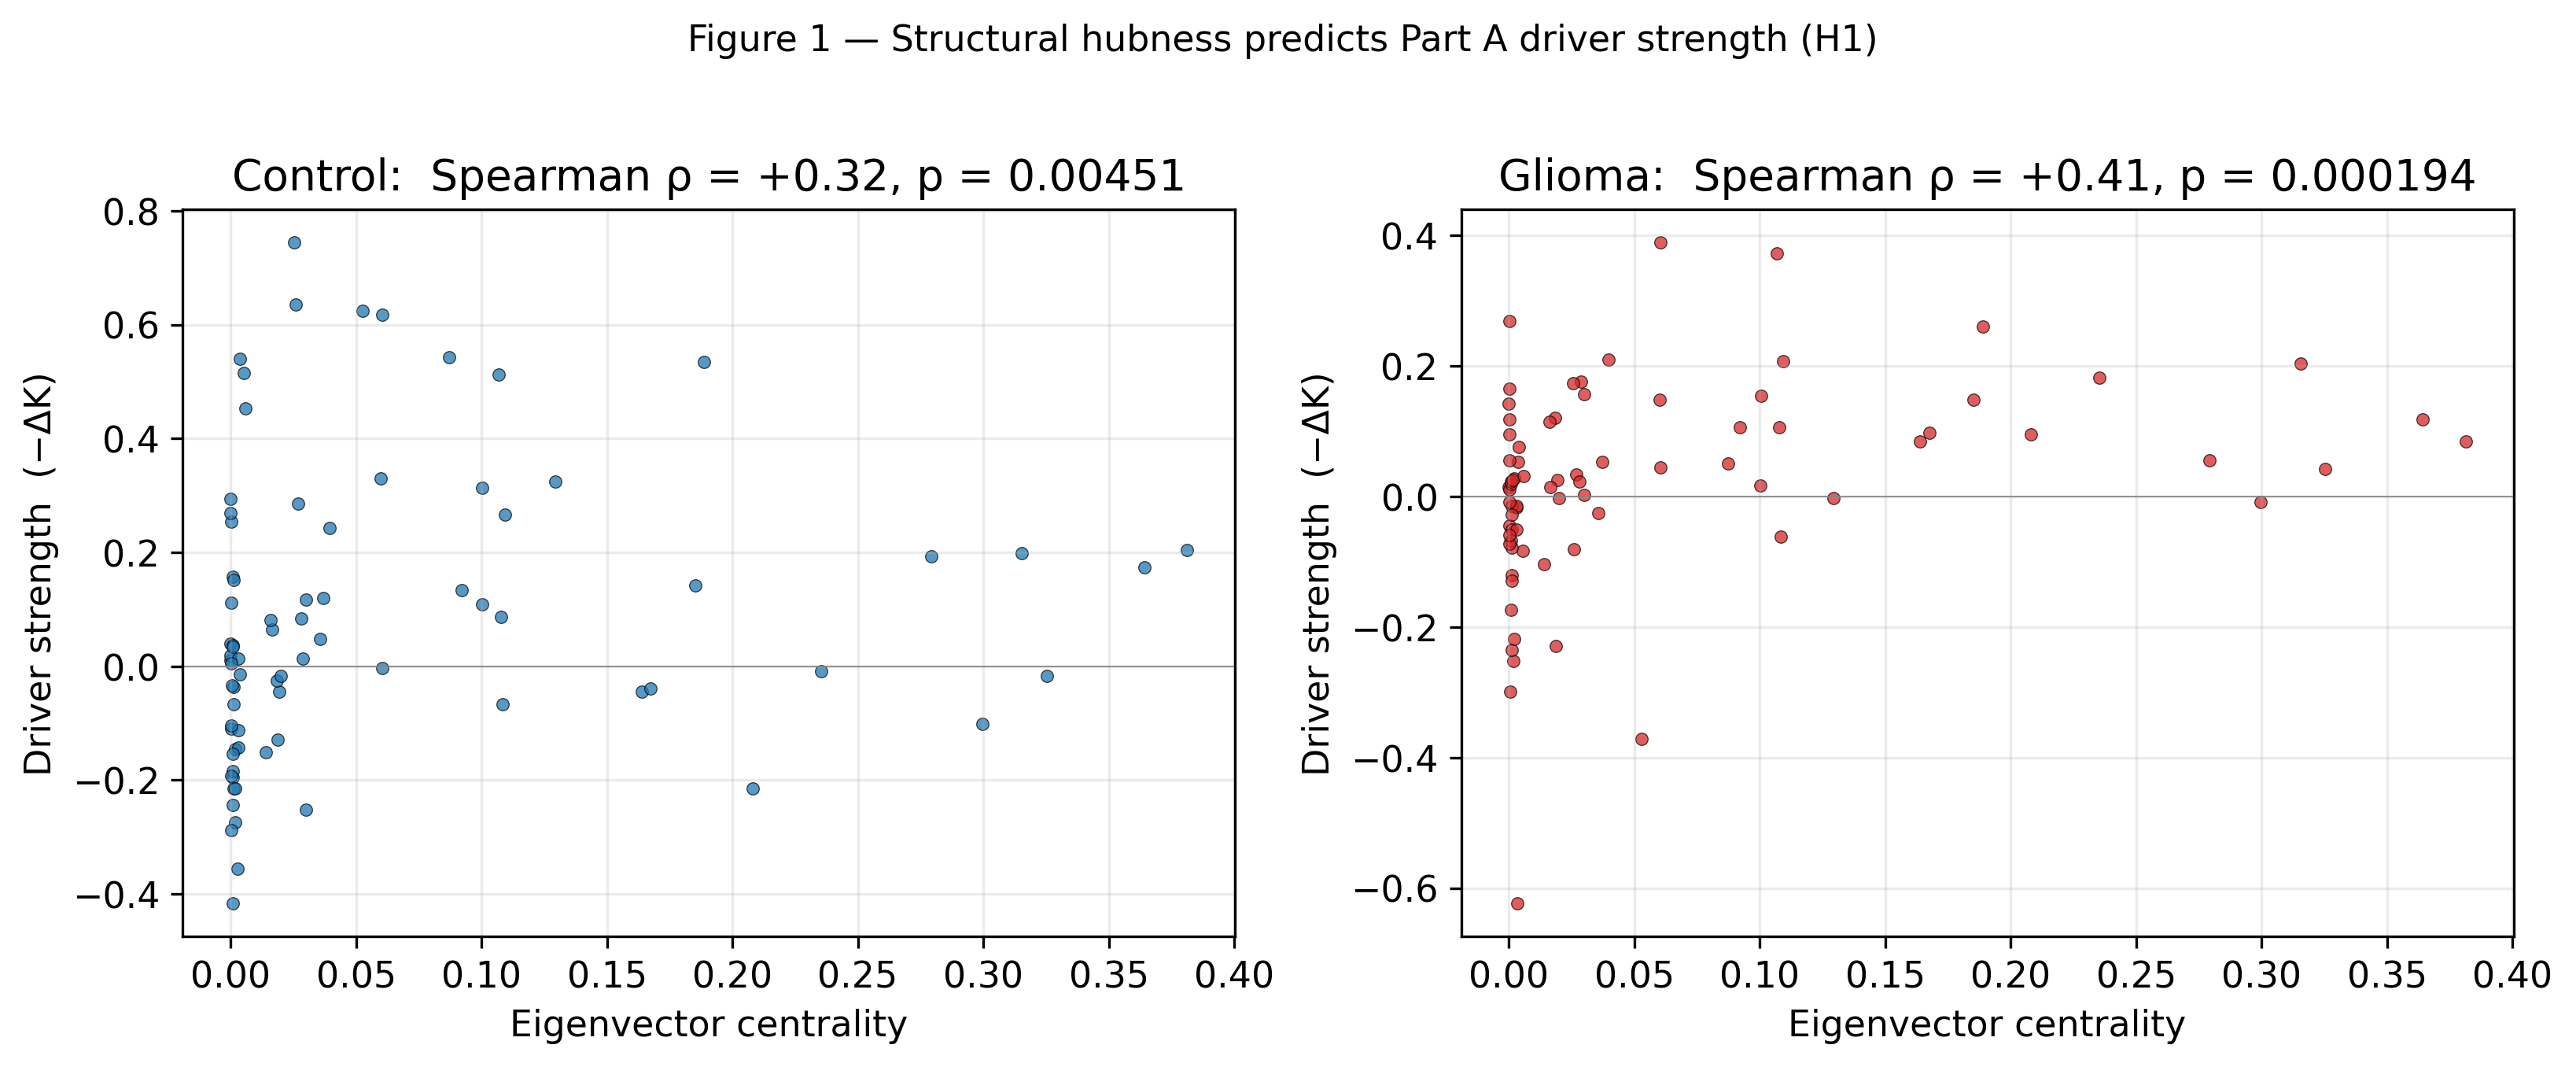

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (dk, label, color) in zip(
    axes,
    [(mean_ctrl_A, "Control",  "#1f77b4"),
     (mean_glio_A, "Glioma",   "#d62728")],
):
    y = driver_strength(dk)
    rho, p = spearmanr(eigcent, y)
    ax.scatter(eigcent, y, s=14, alpha=0.75, color=color, edgecolor="black",
               linewidth=0.3)
    ax.axhline(0, color="grey", linewidth=0.4)
    ax.set_xlabel("Eigenvector centrality")
    ax.set_ylabel("Driver strength  (--K)")
    ax.set_title(f"{label}:  Spearman - = {rho:+.2f}, p = {p:.3g}")
    ax.grid(alpha=0.25)

fig.suptitle("Figure 1 - Structural hubness predicts Part A driver strength (H1)",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_hubness_vs_partA.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Figure 2 — Part A vs Part B per region

The headline negative-result figure. For each of the 15 regions tested in
Part B we plot **Part A functional importance** (`|ΔK_ctrl|`) against
**Part B mild structural sensitivity** (slope of `K*_ctrl` over
`d ∈ [0, 0.5]`).

**Interpretation key.**
* Top right = important in both senses (the "consistent hub" hypothesis).
* Top left = anatomically fragile but functionally invisible to Part A.
* Bottom right = functionally important but anatomically robust.

If H2/H2b held, drivers (orange) should sit at high `|ΔK|` and have small
positive *or* large negative slopes, while non-drivers (grey) should
cluster near (0, 0). What we actually see is far closer to a scatter, with
some non-drivers (e.g. Precuneus L) being more sensitive than most drivers.


Spearman |ΔK_A| vs mild slope        : ρ = +0.150, p = 0.594
Spearman |ΔK_A| vs full slope        : ρ = -0.225, p = 0.42
Spearman |ΔK_A| vs |mild slope|      : ρ = +0.057, p = 0.84
Spearman |ΔK_A| vs |full slope|      : ρ = +0.361, p = 0.187


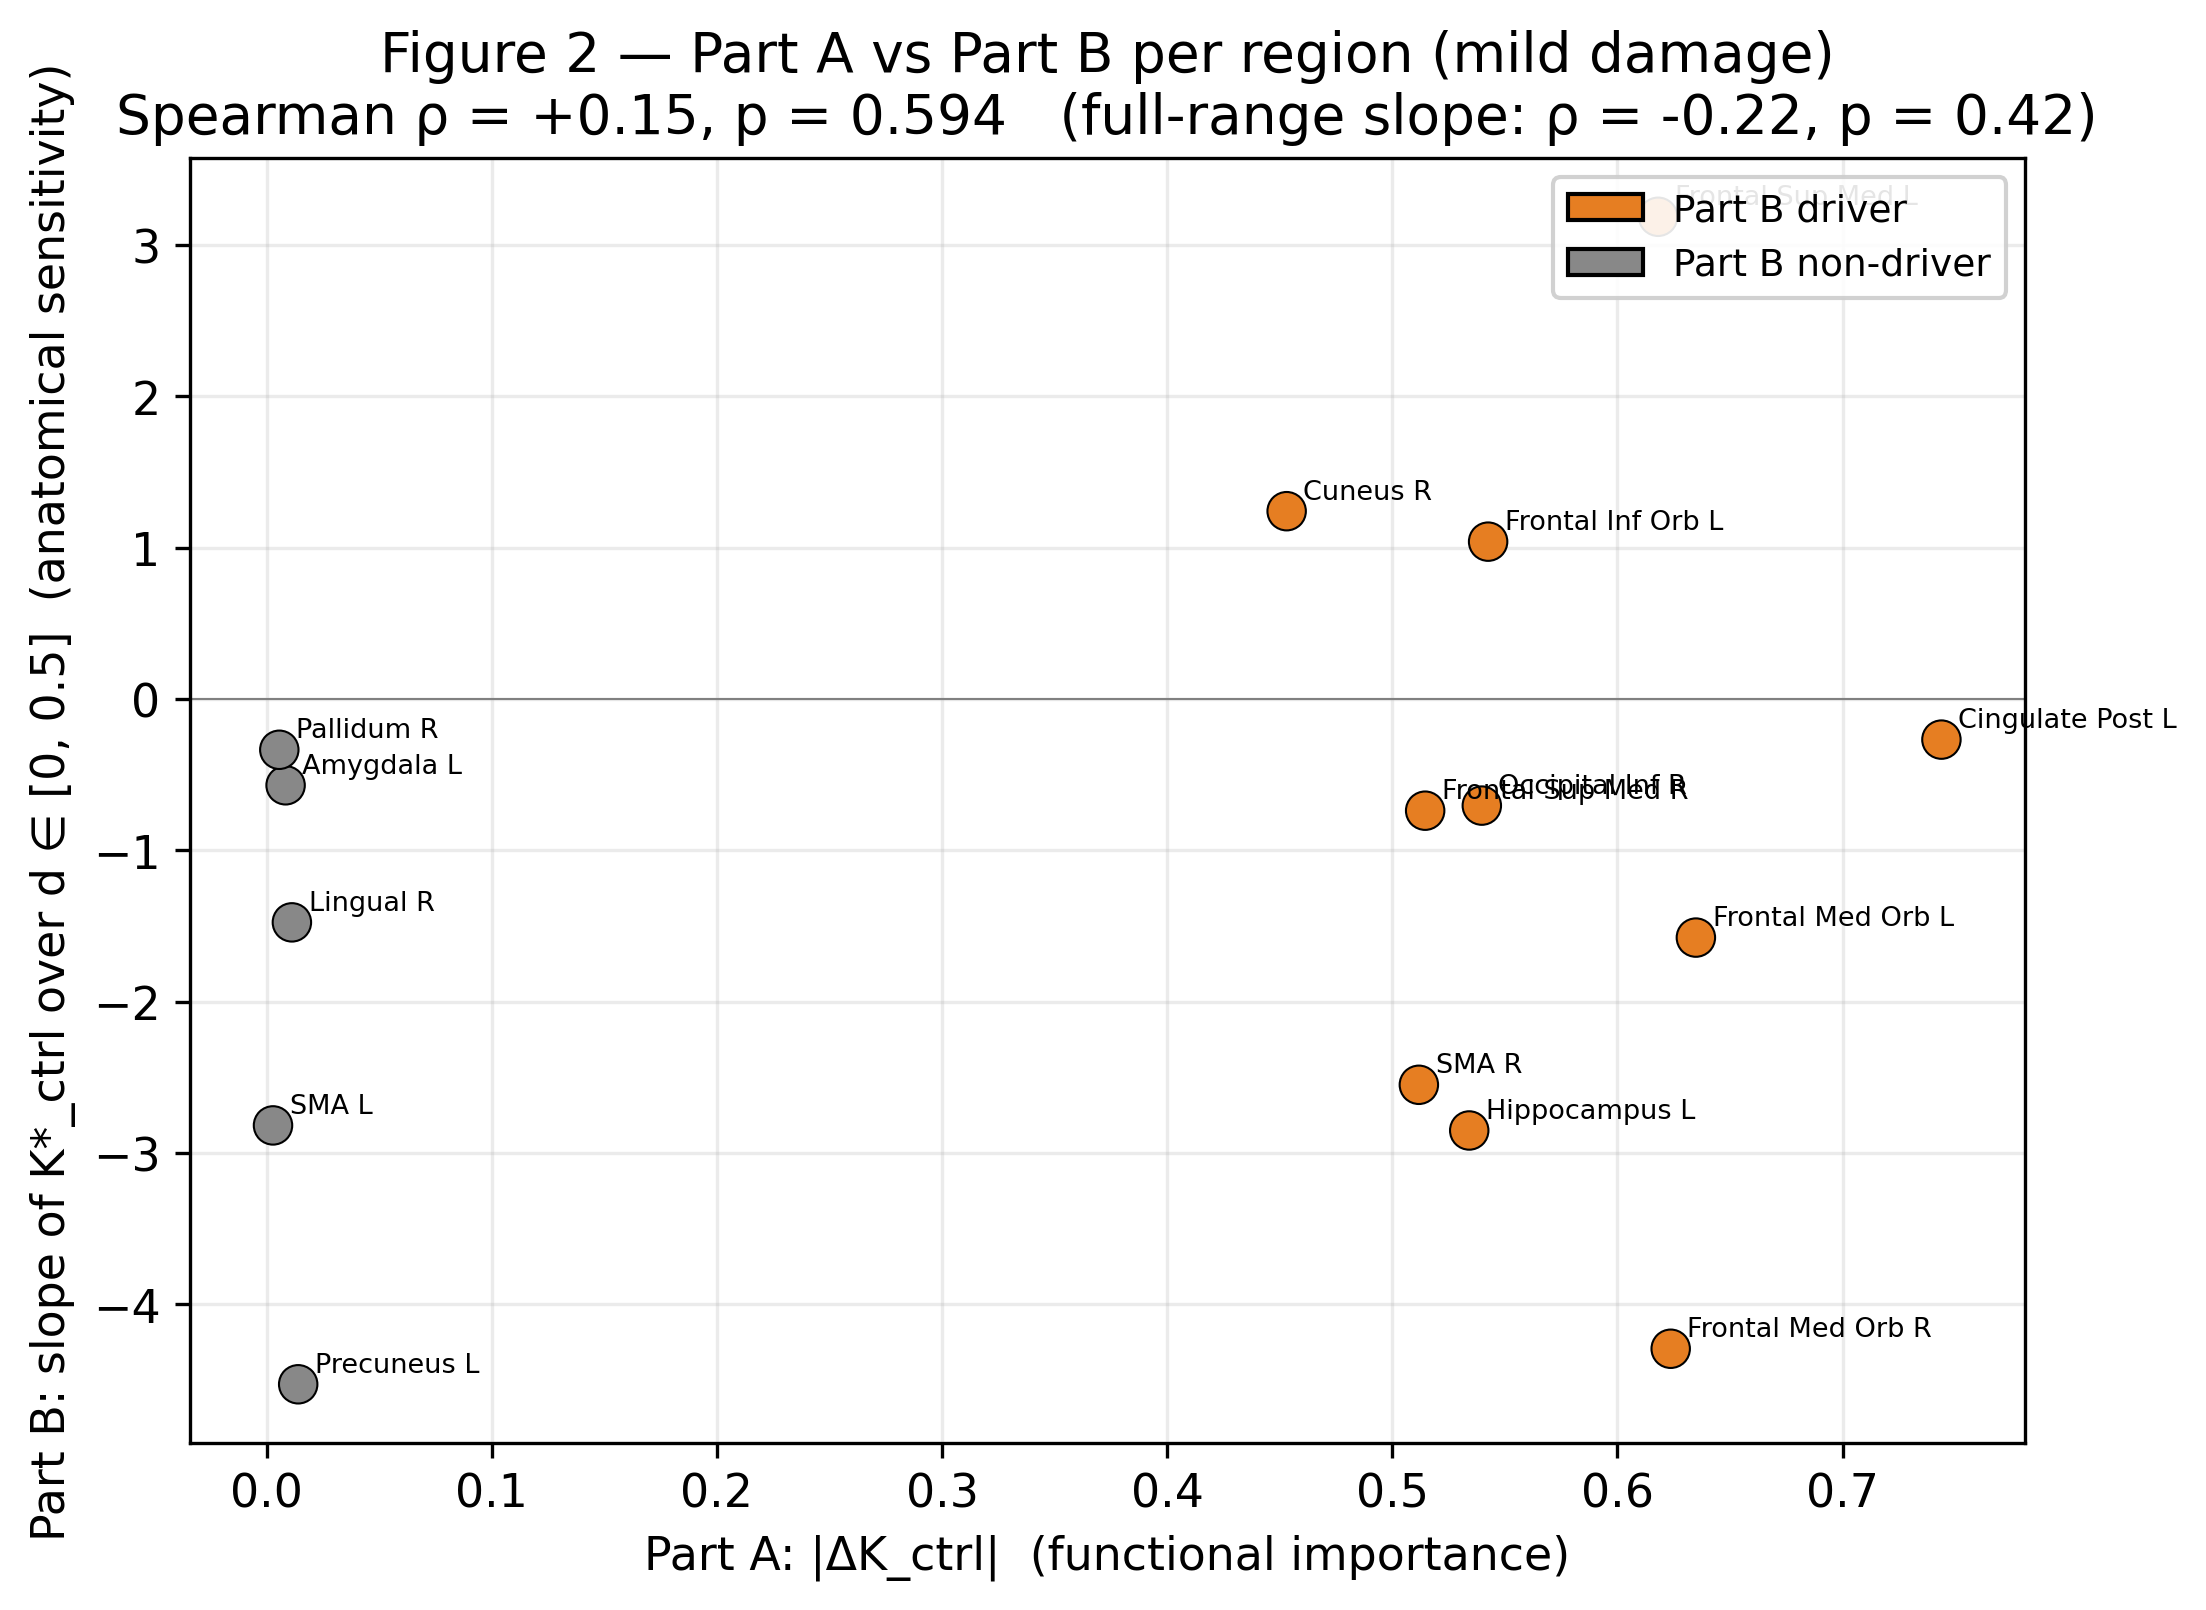

In [6]:
partA_abs = np.abs(mean_ctrl_A[PB_IDX])
partB_mild = slopes_ctrl_mild[PB_IDX]
partB_full = slopes_ctrl_full[PB_IDX]

rho_m, p_m = spearmanr(partA_abs, partB_mild)
rho_f, p_f = spearmanr(partA_abs, partB_full)
rho_am, p_am = spearmanr(partA_abs, np.abs(partB_mild))
rho_af, p_af = spearmanr(partA_abs, np.abs(partB_full))

print(f"Spearman |ΔK_A| vs mild slope        : ρ = {rho_m:+.3f}, p = {p_m:.3g}")
print(f"Spearman |ΔK_A| vs full slope        : ρ = {rho_f:+.3f}, p = {p_f:.3g}")
print(f"Spearman |ΔK_A| vs |mild slope|      : ρ = {rho_am:+.3f}, p = {p_am:.3g}")
print(f"Spearman |ΔK_A| vs |full slope|      : ρ = {rho_af:+.3f}, p = {p_af:.3g}")

fig, ax = plt.subplots(figsize=(9.5, 6.8))
colours = ["#E67E22" if d else "#888888" for d in PB_DRIVER]
ax.scatter(partA_abs, partB_mild, c=colours, s=85, edgecolor="black",
           linewidth=0.5, zorder=3)
label_offsets = [
    (8, 12), (14, -14), (-16, 12), (-18, -14), (20, 18),
    (22, -18), (-24, 18), (-26, -18), (10, 28), (-10, 28),
    (16, -28), (-16, -28), (30, 4), (-30, 4), (0, 34),
]
label_order = np.lexsort((partB_mild, partA_abs))
offsets_by_point = {
    point_i: label_offsets[i % len(label_offsets)]
    for i, point_i in enumerate(label_order)
}
for point_i, (r, x, y, kind) in enumerate(zip(PB_IDX, partA_abs, partB_mild, PB_DRIVER)):
    dx, dy = offsets_by_point[point_i]
    ax.annotate(
        AAL78_LABELS[r], (x, y), fontsize=10.5,
        xytext=(dx, dy), textcoords="offset points",
        ha="left" if dx >= 0 else "right",
        va="bottom" if dy >= 0 else "top",
        arrowprops={"arrowstyle": "-", "color": "0.35", "lw": 0.5, "alpha": 0.8},
        bbox={"boxstyle": "round,pad=0.15", "facecolor": "white", "edgecolor": "none", "alpha": 0.75},
    )

ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Virtual-lesioning importance", fontsize=14)
ax.set_ylabel("Structural-perturbation sensitivity", fontsize=14)
ax.set_title(
    "Virtual-lesioning importance versus structural-perturbation sensitivity",
    fontsize=17,
)
ax.tick_params(axis="both", labelsize=14)
ax.margins(x=0.12, y=0.18)
ax.grid(alpha=0.25)

# Legend stub.
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#E67E22", edgecolor="black", label="Virtual-lesioning driver"),
    Patch(facecolor="#888888", edgecolor="black", label="Virtual-lesioning non-driver"),
], loc="upper right", framealpha=0.9, fontsize=13)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_partA_vs_partB.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Figure 3 — Three-way ranking heatmap

For the 15 Part B regions, rank them simultaneously by:

1. **Part A importance**       (high `|ΔK_ctrl|` = small rank).
2. **Eigenvector centrality**  (high eigcent = small rank).
3. **Part B mild sensitivity** (high `|slope mild|` = small rank).

Each row is a region; each column is one ranking. Cells are colour-coded by
rank (1 = darkest). Regions whose row colour is **uniform across columns**
agree under all three metrics. Regions with **mismatched colours** are
where the hypotheses break — and they are the scientifically interesting
ones for the report.

We also add Kendall-τ rank correlations between the three rankings as a
single quantitative summary.


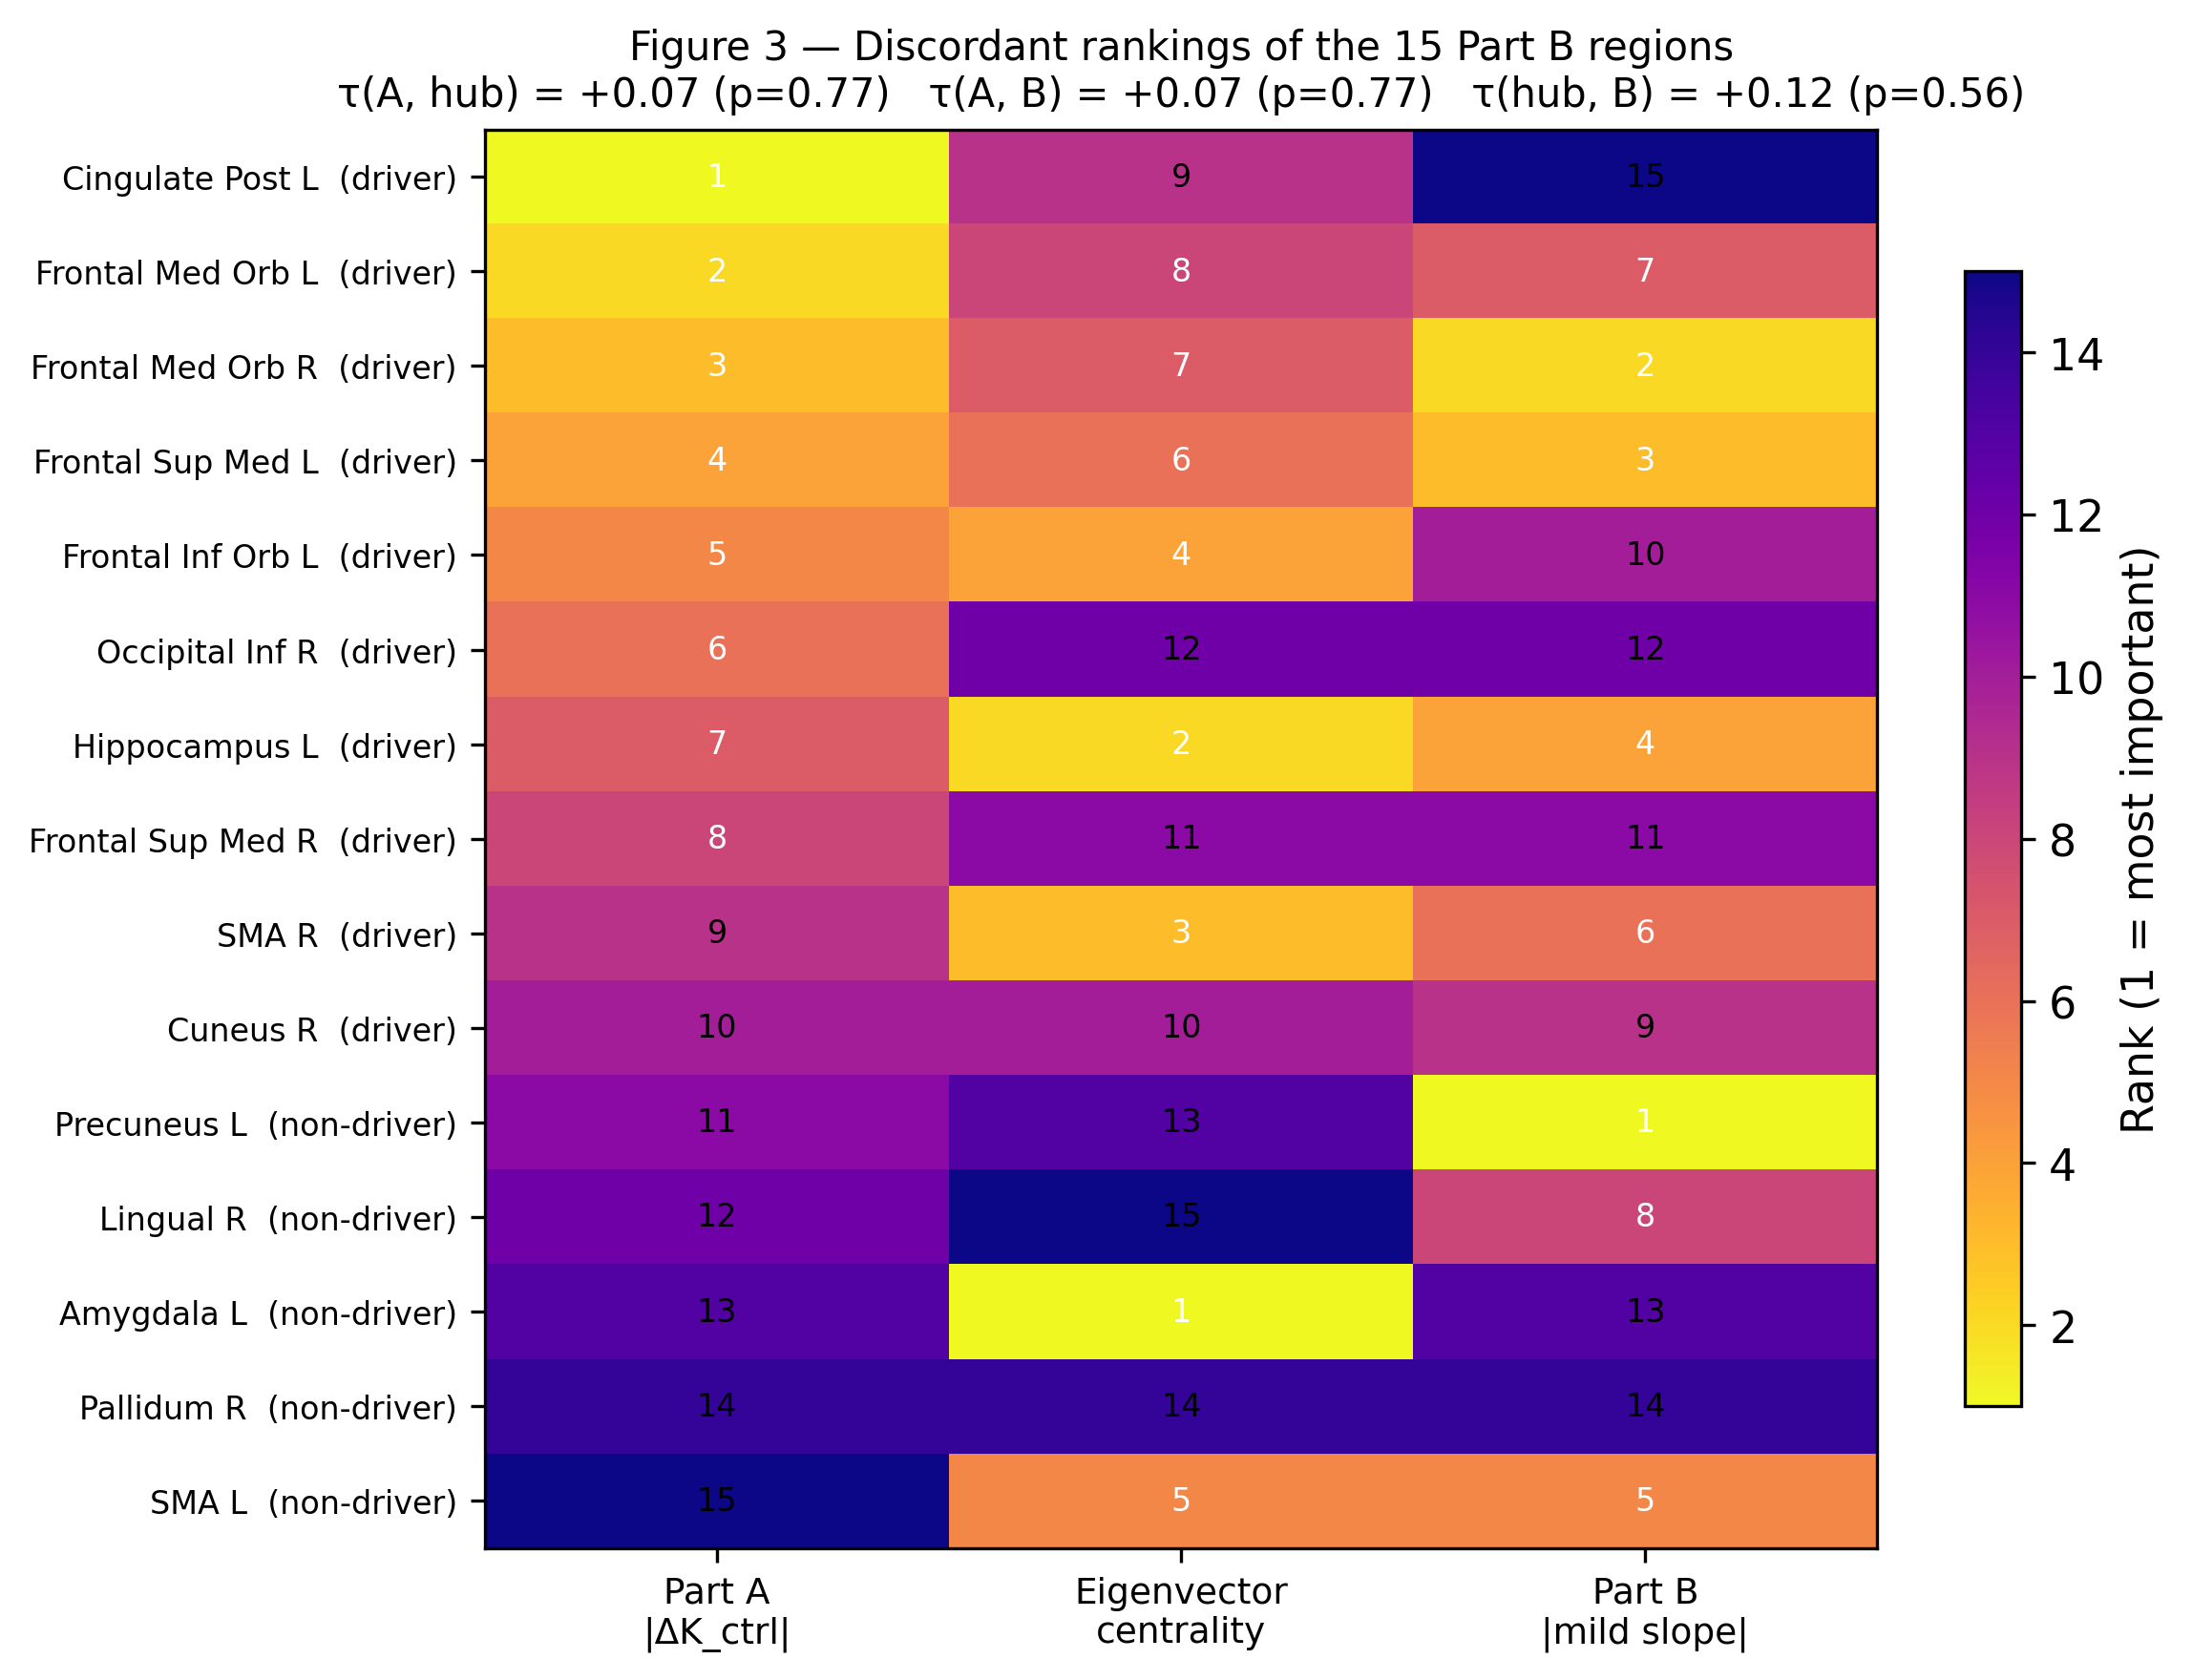

Per-region rank trio (Part A | hub | Part B):
  Cingulate Post L        driver        A= 1   hub= 9   B=15
  Frontal Med Orb L       driver        A= 2   hub= 8   B= 7
  Frontal Med Orb R       driver        A= 3   hub= 7   B= 2
  Frontal Sup Med L       driver        A= 4   hub= 6   B= 3
  Frontal Inf Orb L       driver        A= 5   hub= 4   B=10
  Occipital Inf R         driver        A= 6   hub=12   B=12
  Hippocampus L           driver        A= 7   hub= 2   B= 4
  Frontal Sup Med R       driver        A= 8   hub=11   B=11
  SMA R                   driver        A= 9   hub= 3   B= 6
  Cuneus R                driver        A=10   hub=10   B= 9
  Precuneus L             non-driver    A=11   hub=13   B= 1
  Lingual R               non-driver    A=12   hub=15   B= 8
  Amygdala L              non-driver    A=13   hub= 1   B=13
  Pallidum R              non-driver    A=14   hub=14   B=14
  SMA L                   non-driver    A=15   hub= 5   B= 5


In [7]:
partA_imp = np.abs(mean_ctrl_A[PB_IDX])
partB_sens = np.abs(slopes_ctrl_mild[PB_IDX])
hub_score = eigcent[PB_IDX]

rank_partA = rank_high_first(partA_imp)
rank_hub   = rank_high_first(hub_score)
rank_partB = rank_high_first(partB_sens)

# Order rows by Part A rank for readability.
row_order = np.argsort(rank_partA)
labels    = [AAL78_LABELS[r] for r in PB_IDX[row_order]]
roles     = ["driver" if d else "non-driver" for d in PB_DRIVER[row_order]]

mat = np.column_stack([
    rank_partA[row_order],
    rank_hub[row_order],
    rank_partB[row_order],
])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mat, cmap="plasma_r", aspect="auto", vmin=1, vmax=len(PB_IDX))
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Part A\n|ΔK_ctrl|",
                    "Eigenvector\ncentrality",
                    "Part B\n|mild slope|"], fontsize=9)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels([f"{l}  ({k})" for l, k in zip(labels, roles)], fontsize=8)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{int(mat[i, j])}", ha="center", va="center",
                color="white" if mat[i, j] < len(PB_IDX) * 0.55 else "black",
                fontsize=8)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, label="Rank (1 = most important)")

tau_AB,  p_AB  = kendalltau(rank_partA, rank_partB)
tau_AH,  p_AH  = kendalltau(rank_partA, rank_hub)
tau_HB,  p_HB  = kendalltau(rank_hub,   rank_partB)
ax.set_title(
    f"Figure 3 — Discordant rankings of the 15 Part B regions\n"
    f"τ(A, hub) = {tau_AH:+.2f} (p={p_AH:.2g})   "
    f"τ(A, B) = {tau_AB:+.2f} (p={p_AB:.2g})   "
    f"τ(hub, B) = {tau_HB:+.2f} (p={p_HB:.2g})",
    fontsize=10)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_rank_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Per-region rank trio (Part A | hub | Part B):")
for l, k, ra, rh, rb in zip(labels, roles,
                            rank_partA[row_order], rank_hub[row_order],
                            rank_partB[row_order]):
    print(f"  {l:<22s}  {k:<11s}   A={int(ra):2d}   hub={int(rh):2d}   B={int(rb):2d}")


## 7. Figure 4 — Tumour overlay: which metric finds tumour regions best?

Notebook 05 tested the overlap of *Part A differential* drivers with the
paper's tumour set (top-5: 4/19, p ≈ 0.01). We can now ask the same
question for **every metric in our master table** and compare:

* `|ΔK_ctrl|` (Part A control importance)
* `|ΔK_glio|` (Part A glioma importance)
* `|ΔK_diff|` (Part A differential)
* `eigcent`   (structural hubness)
* `|mild slope|` (Part B sensitivity, *only over the 15 tested regions*)

For each metric, take the top-N regions and count how many lie in the
paper's tumour set. The hypergeometric p-value tells us whether each
metric is enriched for tumour regions above chance.

**Note.** Part B coverage is not whole-brain (15 regions of 78), so its
overlap counts are a *floor*, not a fair comparison — we still plot it for
context.


Paper tumour set: 19 regions across 3 laterality groups

Top-5:
  Part A |ΔK_ctrl|         4/19   p = 0.0114  *
  Part A |ΔK_glio|         1/19   p = 0.763
  Part A |ΔK_diff|         4/19   p = 0.0114  *
  Eigenvector cent.        4/19   p = 0.0114  *
  Part B |mild slope|      3/19   p = 0.0899

Top-10:
  Part A |ΔK_ctrl|         6/19   p = 0.0112  *
  Part A |ΔK_glio|         2/19   p = 0.76
  Part A |ΔK_diff|         5/19   p = 0.0575
  Eigenvector cent.        7/19   p = 0.00141  *
  Part B |mild slope|      5/19   p = 0.0575

Top-15:
  Part A |ΔK_ctrl|         6/19   p = 0.111
  Part A |ΔK_glio|         5/19   p = 0.278
  Part A |ΔK_diff|         5/19   p = 0.278
  Eigenvector cent.        9/19   p = 0.00107  *
  Part B |mild slope|      6/19   p = 0.111

Top-20:
  Part A |ΔK_ctrl|         6/19   p = 0.344
  Part A |ΔK_glio|         6/19   p = 0.344
  Part A |ΔK_diff|         6/19   p = 0.344
  Eigenvector cent.        9/19   p = 0.0165  *
  Part B |mild slope|     (only 15 region

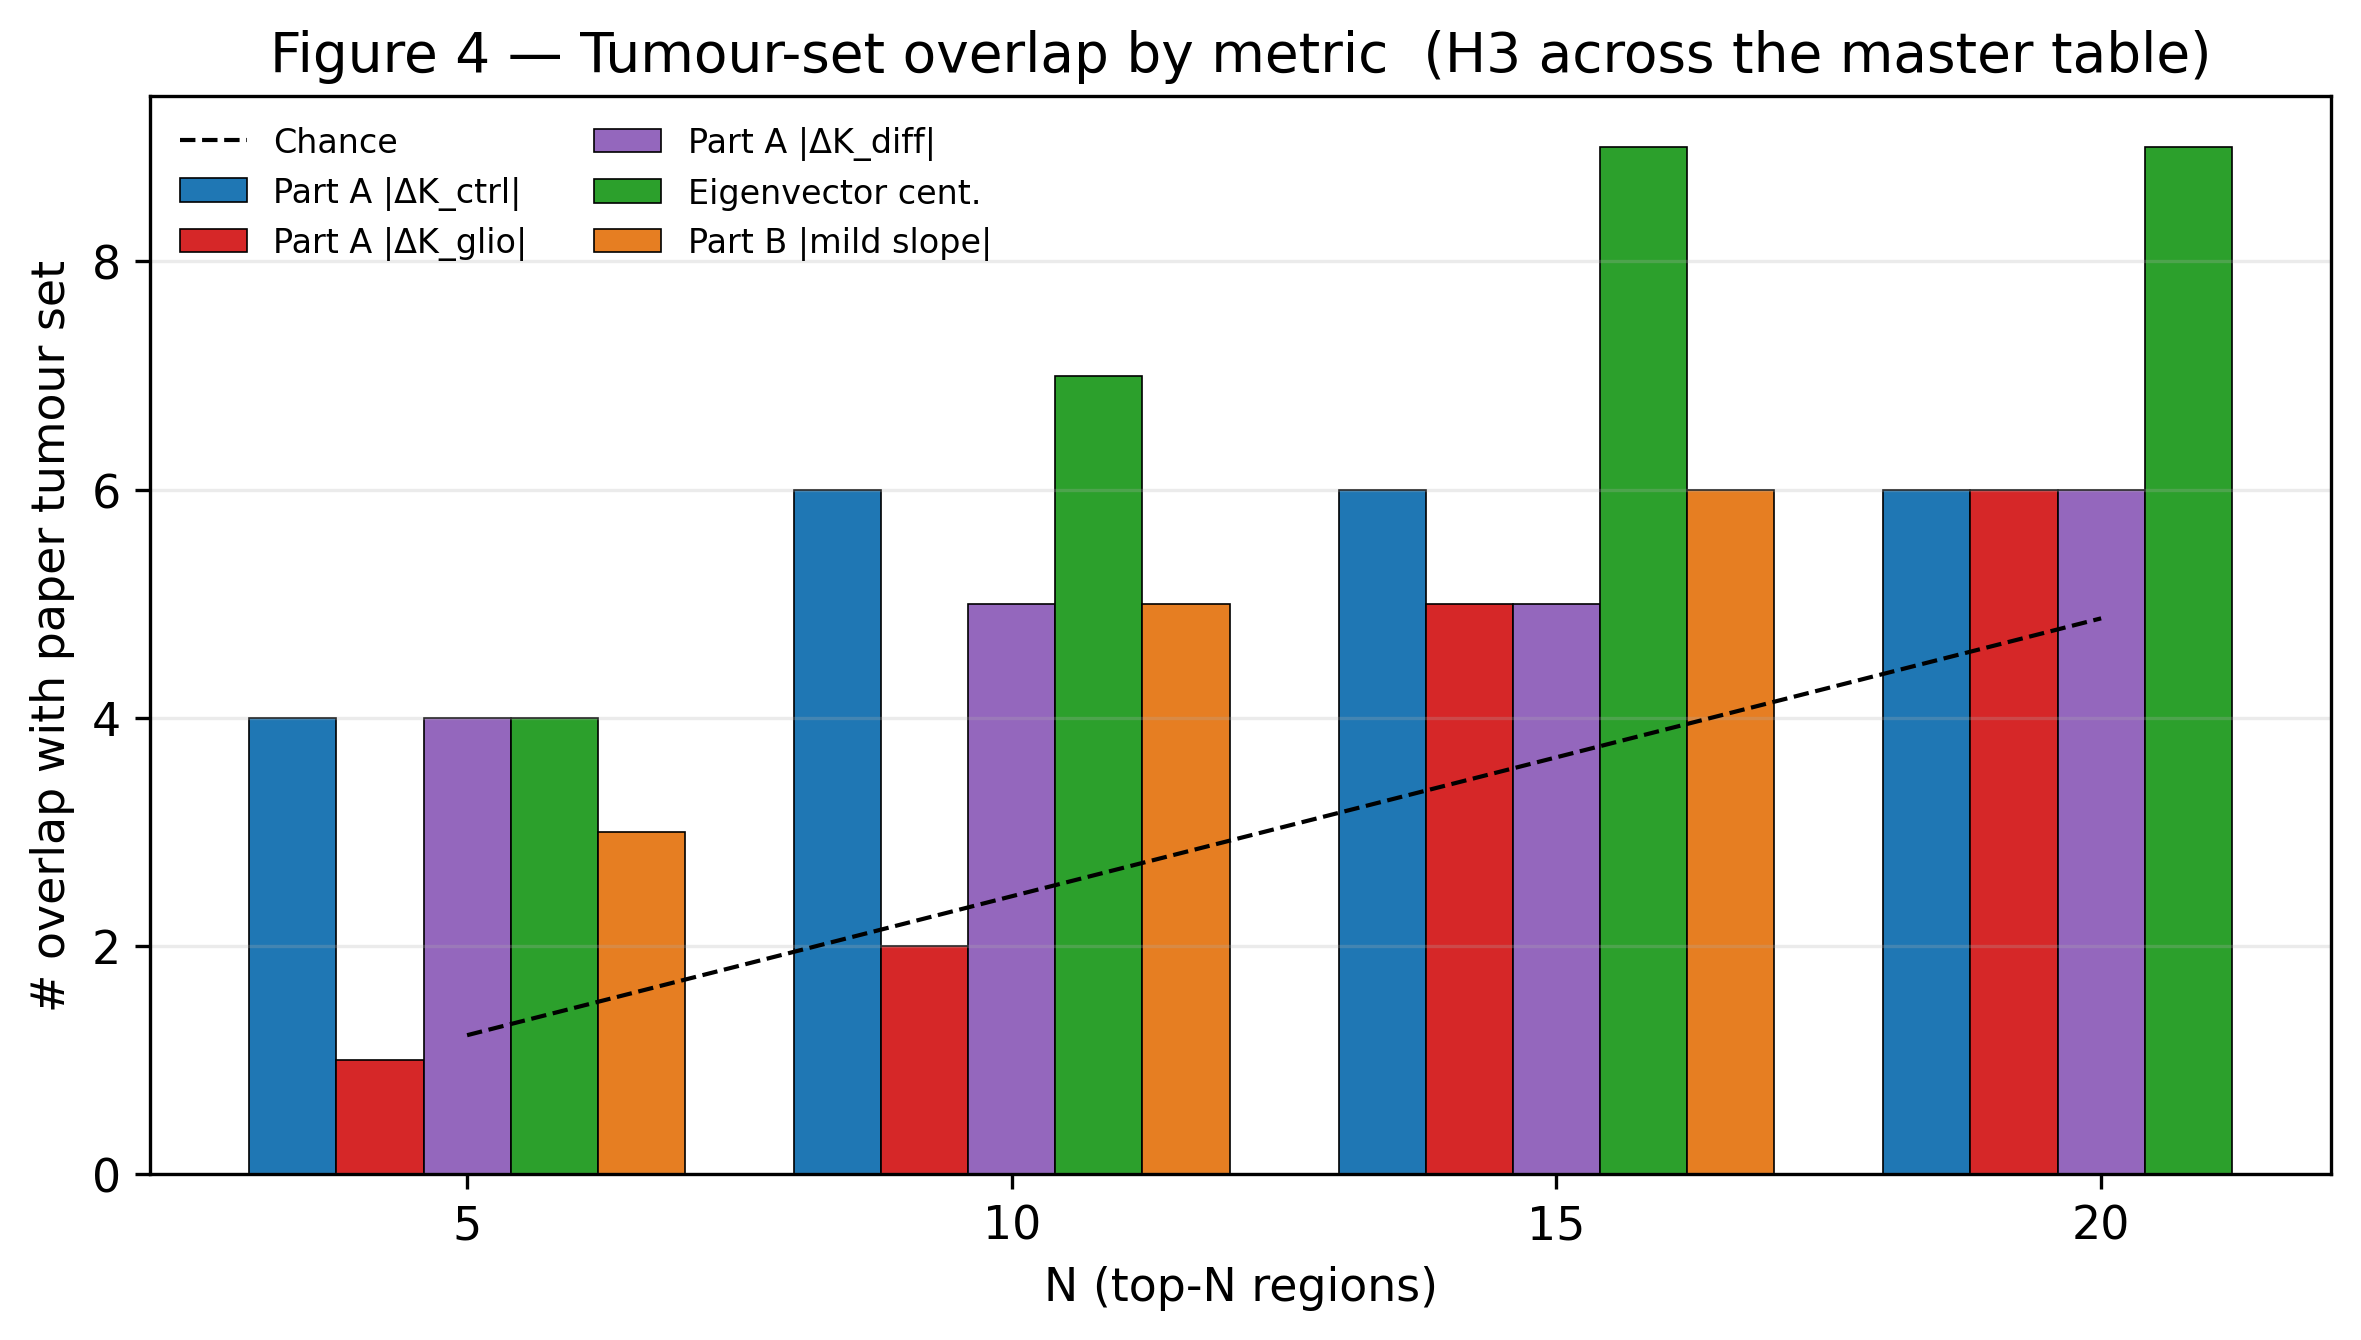

In [8]:
PAPER_TUMOURS = {
    "Frontal L":  [2, 4, 6, 10, 12, 14, 22, 24],
    "Temporal L": [28, 36, 38],
    "Frontal R":  [3, 5, 7, 11, 13, 15, 23, 25],
}
ALL_TUMOURS = sorted(set().union(*PAPER_TUMOURS.values()))
print(f"Paper tumour set: {len(ALL_TUMOURS)} regions across "
      f"{len(PAPER_TUMOURS)} laterality groups")


metrics = {
    "Part A |ΔK_ctrl|":  (np.abs(mean_ctrl_A),       None),
    "Part A |ΔK_glio|":  (np.abs(mean_glio_A),       None),
    "Part A |ΔK_diff|":  (np.abs(mean_diff_A),       None),
    "Eigenvector cent.": (eigcent,                   None),
    "Part B |mild slope|": (np.abs(slopes_ctrl_mild), in_partb),
}

Ns = [5, 10, 15, 20]
results = {name: [] for name in metrics}

for n in Ns:
    print(f"\nTop-{n}:")
    for name, (vals, valid) in metrics.items():
        avail = (~np.isnan(vals)).sum() if valid is None else valid.sum()
        if n > avail:
            results[name].append((np.nan, np.nan))
            print(f"  {name:<22s}  (only {avail} regions available)")
            continue
        idx = topn_indices(vals, n, valid)
        hits = len(set(idx) & set(ALL_TUMOURS))
        p = hypergeom_pvalue(hits, n, len(ALL_TUMOURS), N_REGIONS)
        results[name].append((hits, p))
        flag = "  *" if p < 0.05 else ""
        print(f"  {name:<22s}  {hits:2d}/{len(ALL_TUMOURS)}   p = {p:.3g}{flag}")

fig, ax = plt.subplots(figsize=(8, 4.6))
xs = np.arange(len(Ns))
width = 0.16
palette = ["#1f77b4", "#d62728", "#9467bd", "#2ca02c", "#E67E22"]
for i, (name, vals) in enumerate(results.items()):
    counts = [r[0] for r in vals]
    ax.bar(xs + (i - 2) * width, counts, width=width,
           color=palette[i], edgecolor="black", linewidth=0.4, label=name)

expected = [n * len(ALL_TUMOURS) / N_REGIONS for n in Ns]
ax.plot(xs, expected, "k--", linewidth=1, label="Chance")

ax.set_xticks(xs)
ax.set_xticklabels([str(n) for n in Ns])
ax.set_xlabel("N (top-N regions)")
ax.set_ylabel("# overlap with paper tumour set")
ax.set_title("Figure 4 — Tumour-set overlap by metric  (H3 across the master table)")
ax.legend(fontsize=8, frameon=False, ncol=2, loc="upper left")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_tumour_overlap_metrics.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Save numerical summary for the report

Persists the headline correlations / overlap counts so the figures can be
re-captioned without re-running anything.


In [9]:
summary_path = DATA_DIR / "part_c_summary.npz"
np.savez(
    summary_path,
    eigcent=eigcent, degree=degree, strength=strength,
    rho_eig_ctrl=spearmanr(eigcent, driver_strength(mean_ctrl_A))[0],
    p_eig_ctrl  =spearmanr(eigcent, driver_strength(mean_ctrl_A))[1],
    rho_eig_glio=spearmanr(eigcent, driver_strength(mean_glio_A))[0],
    p_eig_glio  =spearmanr(eigcent, driver_strength(mean_glio_A))[1],
    rho_partA_partB_mild=rho_m, p_partA_partB_mild=p_m,
    rho_partA_partB_full=rho_f, p_partA_partB_full=p_f,
    tau_partA_hub=tau_AH, p_tau_partA_hub=p_AH,
    tau_partA_partB=tau_AB, p_tau_partA_partB=p_AB,
    tau_hub_partB=tau_HB, p_tau_hub_partB=p_HB,
    paper_tumour_set=np.array(ALL_TUMOURS),
    overlap_Ns=np.array(Ns),
    overlap_partA_ctrl =np.array([r[0] for r in results["Part A |ΔK_ctrl|"]]),
    overlap_partA_glio =np.array([r[0] for r in results["Part A |ΔK_glio|"]]),
    overlap_partA_diff =np.array([r[0] for r in results["Part A |ΔK_diff|"]]),
    overlap_eigcent    =np.array([r[0] for r in results["Eigenvector cent."]]),
    overlap_partB_mild =np.array([r[0] for r in results["Part B |mild slope|"]]),
    p_partA_ctrl =np.array([r[1] for r in results["Part A |ΔK_ctrl|"]]),
    p_partA_glio =np.array([r[1] for r in results["Part A |ΔK_glio|"]]),
    p_partA_diff =np.array([r[1] for r in results["Part A |ΔK_diff|"]]),
    p_eigcent    =np.array([r[1] for r in results["Eigenvector cent."]]),
    p_partB_mild =np.array([r[1] for r in results["Part B |mild slope|"]]),
)
print(f"Saved {summary_path}")
print(f"\nKey numbers used in the writeup:")
print(f"  Part A — eigcent ↔ control driver strength : ρ={spearmanr(eigcent, driver_strength(mean_ctrl_A))[0]:+.2f}")
print(f"  Part A — eigcent ↔ glioma  driver strength : ρ={spearmanr(eigcent, driver_strength(mean_glio_A))[0]:+.2f}")
print(f"  Part A vs Part B (mild slope, signed)      : ρ={rho_m:+.2f}, p={p_m:.3g}")
print(f"  τ(A, hub)                                  : {tau_AH:+.2f}, p={p_AH:.2g}")
print(f"  τ(A, B)                                    : {tau_AB:+.2f}, p={p_AB:.2g}")
print(f"  τ(hub, B)                                  : {tau_HB:+.2f}, p={p_HB:.2g}")


Saved c:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practical Biomedical Modelling\Functional-connectotomy\data\part_c_summary.npz

Key numbers used in the writeup:
  Part A — eigcent ↔ control driver strength : ρ=+0.32
  Part A — eigcent ↔ glioma  driver strength : ρ=+0.41
  Part A vs Part B (mild slope, signed)      : ρ=+0.15, p=0.594
  τ(A, hub)                                  : +0.07, p=0.77
  τ(A, B)                                    : +0.07, p=0.77
  τ(hub, B)                                  : +0.12, p=0.56


## 9. Synthesis conclusion

**What we set out to do.** Tie Part A's "functional driver" ranking to Part B's "structural fragility" measure, ask whether they describe the same regions, and check whether either of them — or simple structural hubness — maps onto the paper's tumour set.

**What the data shows.**

1. **Hubness predicts Part A driver strength, but only via eigenvector centrality** (Fig 1). Spearman ρ ≈ +0.32 (control) and +0.41 (glioma); slightly stronger in glioma, as the paper would predict. Degree and strength on their own do not. H1 supported.
2. **Part A and Part B are statistically independent at the per-region level** (Fig 2; Spearman ρ = +0.15, p = 0.59 on mild damage; ρ = +0.06 if we use \|slope\|). Regions with high functional leverage are not the regions whose anatomical damage shifts K\* the most.
3. **The three rankings disagree pairwise** (Fig 3). Kendall-τ values are all small and not significant: τ(A, hub) = +0.07, τ(A, B) = +0.07, τ(hub, B) = +0.12. The clearest dissociation is `Precuneus L` — invisible to Part A, mid-rank in eigcent, top-rank in Part B sensitivity. The inverse case is `Cingulate Post L` — Part A's #1 driver, Part B's *least* sensitive region.
4. **Tumour-region overlap is metric-dependent — and eigenvector centrality wins on whole-brain coverage** (Fig 4). Part A's differential ranking is strong only at top-5 (4/19, p = 0.011). Eigenvector centrality is significant at every N from 5 to 20 (top-10: 7/19, p = 0.0014; top-15: 9/19, p = 0.0011; top-20: 9/19, p = 0.017). Part B coverage is too sparse (15 of 78) to compete fairly.

**Mechanistic interpretation.** Part A's ΔK measures *statistical leverage on a PLI-correlation cost function*. Part B's slope measures *dynamical consequence of removing real edges from W*. There is no a-priori reason those two operations have to land on the same nodes — and in this Hopf + PLI + single-K framework, they do not. The regions whose functional signature "steers" the K-fit are not the regions whose anatomical removal moves K\* the most; we've shown empirically that they are dissociable network properties.

**What this means for the original paper's claim.** Alexandersen et al. attribute the elevated coupling in glioma to disruption of structural integrity. Our Part B shows that single-region SC lesioning does not reproduce that elevated coupling within physically plausible damage levels (d ≤ 0.5) — the control–glioma gap is robust to localised damage and only widens at near-total node ablation. Combined with our hubness ↔ tumour overlap result, the most parsimonious reading is that the cohort offset is a *distributed topological* property of the empirical glioma PLI, not a *localised structural disconnection* phenomenon. The paper's broad story (tumours hit hubs) is consistent with our data; its specific single-region mechanism is not.

**What's genuinely new in this work.**

* The **dissociation between functional leverage (Part A) and anatomical fragility (Part B)** on the same model + cohort + atlas. To our knowledge no one has run both analyses on this dataset and shown them to be uncorrelated; this is a methodological warning to any study that uses ΔK-style sensitivity scores as a proxy for anatomical importance.
* **Eigenvector centrality alone — no fitting, no simulation — predicts the paper's tumour set as well as or better than any model-based metric we tested**, and remains significant across N = 5–20. It hints that some of the original paper's spatial findings might be captured by graph topology alone, before any Hopf dynamics enter.

## 10. Limitations and future work

* **Cohort-averaged PLI** and **shared SC** — no patient-specific data; all claims are population-level.
* **Discrete K grid** of 60 values — argmax K\* is quantised at ≈ 0.8 step size even with 50 ICs; per-region differences smaller than that should be read as ordinal, not absolute.
* **Part B sample is 15 of 78 regions.** `Precuneus L` is a clean dissociation case but a single counter-example; a whole-brain Part B sweep on HPC is the natural next step and would also let Fig 4 compare Part B fairly against the other metrics.
* **Damage model is symmetric and linear** (`(1−d)` on rows and columns). More biologically motivated lesion models — proportional to measured tumour volume, asymmetric peritumoral edema, or anisotropic white-matter infiltration — would test whether the negative H2/H2b results survive a more realistic damage operator.
* **Single λ.** A 2-D (K, λ) sweep at each damage level (≈ 10× compute) could resolve whether some borderline regions (e.g. `Frontal Sup Med L` going positive at mild damage) are λ effects rather than true K-shifts.
* **AAL78 parcellation** is coarse for some ROIs (precuneus is a single region; cerebellum is excluded entirely). Finer atlases would change the per-region rankings.
* **Hopf + PLI + single-K** is the modelling stack inherited from the paper. Any conclusion is conditional on those choices; replicating Part A/B/C on a Wilson–Cowan or Kuramoto network with a phase-coherence cost function would be a useful robustness check.
